# Import libraries

In [2]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import emcee
import corner

# Define constants

In [3]:
c = 299792.458 #is this in the correct units?
f0 = 6.61* 10**-9 * 10**(-7) * (3.2408*10**(-25))**(-2)
megaparsec = 3.0856775814913673 * 10**10

# Some key functions

In [4]:
#order of variables: z, omega_k, omega_M, omega_DE, H0, rc

def Friedmann_eq2(z, theta):
    omega_k, omega_M, H0, w = theta
    omega_DE = 1 - omega_k - omega_M
    H2 = (omega_M*(1+z)**3 + omega_DE*(1+z)**(3*(1+w)) - omega_k*(1+z)**2)
    return H2

def integrand(z, theta):
    return 1/np.sqrt(Friedmann_eq2(z, theta))

def co_moving_dist(z_up, theta):
    z_up = np.concatenate(([0], z_up))
    r_cm = scp.integrate.odeint(lambda y, t: integrand(t, theta), 0, z_up)
    r_c = np.delete(r_cm, 0)
    return np.ndarray.flatten(r_c)

def Sk(omega_k, H0, rc): #units issue?
    if omega_k == 0:
        return c*rc/H0
    if omega_k < 0:
        return (c/(H0*np.sqrt(-omega_k)))*np.sin(np.sqrt(-omega_k)*rc)
    return (c/(H0*np.sqrt(omega_k)))*np.sinh(np.sqrt(omega_k)*rc)

def dist_modulus(z, theta):
    omega_k, omega_M, H0, w = theta
    rc = co_moving_dist(z, theta)
    s_k = Sk(omega_k, H0, rc)
    dl = (1+z)*s_k
    if not np.all(dl>0):
        print(f"luminosity distance isn't positive, {dl}, {s_k}, {rc}, {theta}")
    dist_mod = 5*np.log10(dl) + 25
    return dist_mod

In [5]:
#different equations of state:

"""w = w0 #wCDM
w = w0 + wa*(1+z)"""


'w = w0 #wCDM\nw = w0 + wa*(1+z)'

# Load the data

In [6]:
sn_z, sn_z_err, sn_mu, sn_mu_err = np.loadtxt("pantheon-plus+SH0ES-SN.txt", usecols=(2,3,4,5), unpack = True)
covmat_file = np.loadtxt("Pantheon+SH0ES_STAT+SYS.cov")
covmat_file_dim = int(covmat_file[0])
covmat_file = np.delete(covmat_file, 0)
covmat = np.zeros((covmat_file_dim, covmat_file_dim))
covmat.shape
for i in range(covmat_file_dim):
    covmat[i] = covmat_file[i*covmat_file_dim:(i+1)*covmat_file_dim]
covmat_inv = np.linalg.inv(covmat)


## Priors

Parameters of model are: {k, H0, omega_M, omega_DE}

Priors are: {k=0, H0~70, etc}

Should priors be uniform or Gaussian over the range? - use uniform unless I have good reasons to use a Gaussian (eg if I use the Planck result as a prior, the prior could be a Gaussian with st dev being the error given by Planck)

In [7]:
H0_prior = 69.02
H0_stdev_prior = 2.08*5
omega_DE_prior = 0.6889
omega_DE_stdev_prior = 0.0056
omega_M_prior = 0.31
omega_M_stdev_prior = 0.04

def log_prior(theta, z):
    omega_k, omega_M, H0, w0 = theta
    H2 = Friedmann_eq2(z, theta)
    if not (-0.5<omega_k<0.5 and np.all(H2>0) and -1<w0<1 and H0>0):
        return -np.inf
    return -0.5*(omega_M-omega_M_prior)**2/omega_M_stdev_prior**2 -0.5*(H0-H0_prior)**2/H0_stdev_prior**2

nparams = 4
nwalkers = 50
pos = np.zeros((nwalkers, nparams))
for i in range(len(pos)):
    pos[i][0] = np.random.uniform(-0.005, 0.005)
    pos[i][1] = np.random.uniform(0.2, 0.4)
    pos[i][2] = np.random.uniform(20, 100)
    pos[i][3] = np.random.uniform(-1,1)
    

# Likelihood function

In [8]:
def log_likelihood(theta, z, mu, covmatrix_inv):
    model = dist_modulus(z, theta)
    resids = mu - model
    chi2 = np.matmul(np.matmul(resids, covmatrix_inv), resids)
    return -0.5*chi2
    


def log_probability(theta, z, mu, covmatrix_inv):
    lp = log_prior(theta, z)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu, covmatrix_inv)


# The MCMC algorithm

Questions to investigate: how many chains should I discard? What is burn in? How many walkers do I need? How many steps should the walkers take?

In [9]:
nsteps = 1000 #number of steps walkers take
nwalkers, ndim = pos.shape
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args = (sn_z, sn_mu, covmat_inv)
)
sampler.run_mcmc(pos, nsteps, progress = True)

100%|██████████| 1000/1000 [01:27<00:00, 11.47it/s]


State([[-2.30929525e-02  3.31018068e-01  7.12013449e+01 -9.21600560e-01]
 [-1.89713314e-01  2.85631171e-01  6.17543485e+01 -8.32538543e-01]
 [-1.36893579e-01  3.00256865e-01  6.39574914e+01 -8.10772329e-01]
 [-1.58744958e-02  2.97477851e-01  7.12954145e+01 -8.16450445e-01]
 [-2.07018536e-01  2.92530857e-01  6.10708081e+01 -8.09900801e-01]
 [ 3.15565758e-02  2.83051260e-01  7.48495306e+01 -7.77990897e-01]
 [ 1.33530365e-01  3.10393112e-01  8.45980467e+01 -8.25458162e-01]
 [-9.19599999e-02  2.52242328e-01  6.66366228e+01 -7.72365917e-01]
 [-4.82895558e-02  2.65187390e-01  6.92915179e+01 -7.78978583e-01]
 [ 5.36186848e-02  2.69080581e-01  7.69034315e+01 -7.87430048e-01]
 [-1.63683853e-01  2.96525943e-01  6.30563282e+01 -8.47329096e-01]
 [ 2.10163892e-02  3.27710218e-01  7.42121521e+01 -8.67959002e-01]
 [-5.12769074e-02  2.47370984e-01  6.90242027e+01 -7.54576322e-01]
 [ 2.13758274e-02  2.92607525e-01  7.41367652e+01 -8.29889731e-01]
 [-2.33178658e-01  2.89921474e-01  5.97855781e+01 -8.200

autocorrelation time is [1788.89895071  176.61183404 1889.47573875  206.79686672]


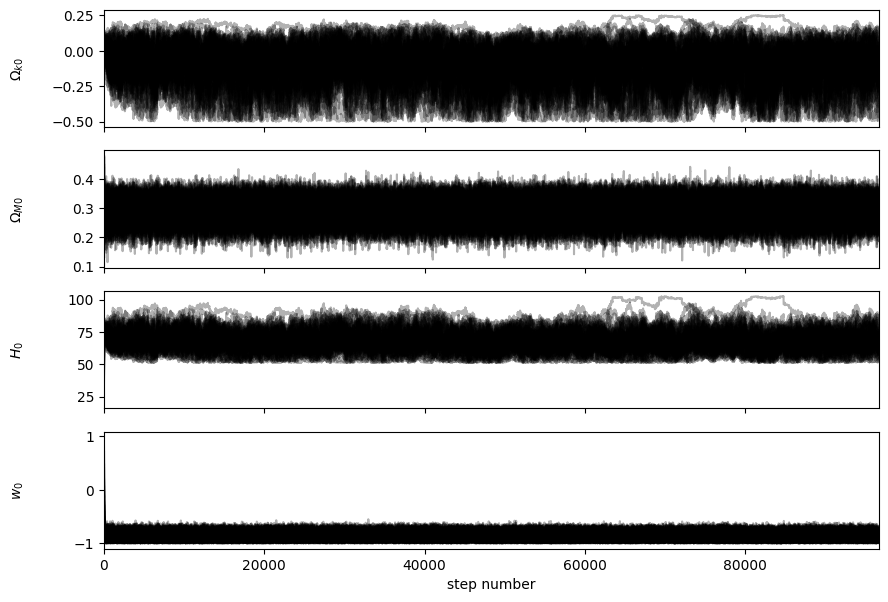

In [21]:
#sampler.run_mcmc(None, 5000, progress = True)
ndiscard = 6000 #how many steps at the beginning of the chain to discard
flat_samples = sampler.get_chain(discard = ndiscard, thin = 15, flat = True)

fig, axes = plt.subplots(nparams, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["$Ω_{k0}$", "$Ω_{M0}$", "$H_{0}$", "$w_{0}$"] 
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");
plt.savefig("walkers_wCDM.png")
print(f"autocorrelation time is {sampler.get_autocorr_time()}")

# Covariance plots

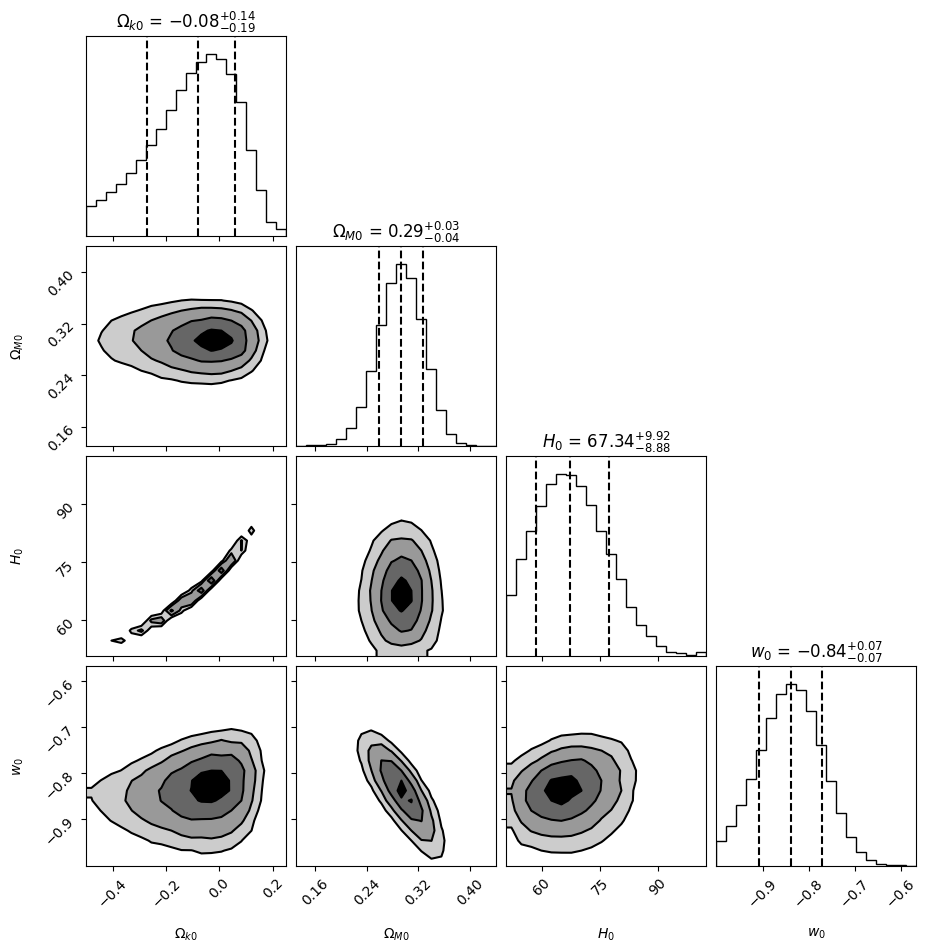

In [22]:
#fig, axs = plt.subplots(4,4)
fig = corner.corner(
    flat_samples, labels = labels, quantiles=[0.16,0.5,0.84], show_titles=True, title_kwargs={"fontsize": 12}, plot_datapoints=False, fill_contours = True
)
plt.savefig("corner_wCDM.png")
#axs[0,0].set_facecolor("lightblue")
plt.show()
#plt.suptitle('CORNER PLOT')
#plt.savefig('test_corner.png')
#plt.show()
plt.close()
#plt.savefig("corner_wCDM.png")

In [23]:

for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]} + {q[1]} - {q[0]}")

$Ω_{k0}$: -0.08151959274242015 + 0.14020901635812105 - 0.19023164013889754
$Ω_{M0}$: 0.29361816889855963 + 0.03358085855480447 - 0.035037838237722996
$H_{0}$: 67.34440808199645 + 9.92027309988731 - 8.88146299006766
$w_{0}$: -0.8379848886161949 + 0.06706329239518627 - 0.07062165404166432


In [24]:
theta_model = np.zeros(nparams)
for i in range(nparams):
    theta_model[i] = np.percentile(flat_samples[:, i], [50])[0]

chi-squared: 1749.5990424669626


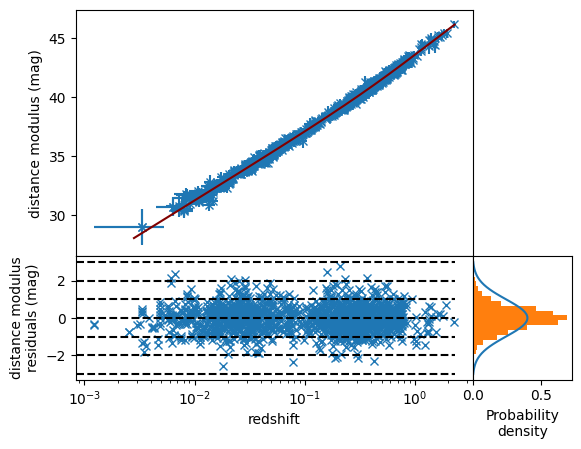

BIC: 1779.3549288365462


In [26]:
model_z = np.linspace(0.001, 2.3, 1000)
model_mu = dist_modulus(model_z, theta_model)
resids = sn_mu - dist_modulus(sn_z, theta_model)
chisqval = np.matmul(np.matmul(resids, covmat_inv), resids)


fig, axs = plt.subplots(2, 2, width_ratios=[4,1], height_ratios=[2,1])
axs[0,0].plot(model_z, model_mu, color = "maroon", zorder = 2)

axs[0,0].errorbar(sn_z, sn_mu, xerr=sn_z_err, yerr = sn_mu_err, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(2,0,2.3, linestyle = "--", color = "black")
norm_resids = (dist_modulus(sn_z, theta_model) - sn_mu)/sn_mu_err
print(f"chi-squared: {chisqval}")
axs[1,0].errorbar(sn_z, norm_resids, marker = "x", linestyle = 'None', zorder = 1)
axs[1,0].hlines(3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-1,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-2,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(-3,0,2.3, linestyle = "--", color = "black")
axs[1,0].hlines(0,0,2.3, linestyle = "--", color = "black", zorder = 2)
axs[1,0].set_xlabel("redshift")
axs[0,0].set_ylabel("distance modulus (mag)")
axs[1,0].set_ylabel("distance modulus\nresiduals (mag)")
fig.subplots_adjust(hspace=0)
fig.subplots_adjust(wspace=0)
#axs[0,0].invert_yaxis()
axs[0,0].set_xscale("log")
axs[1,0].set_xscale("log")
axs[0,1].remove()
axs[1,1].get_yaxis().set_visible(False)
xs = np.linspace(-3,3)
axs[1,1].plot(scp.stats.norm.pdf(xs, 0, 1), xs)
axs[1,1].set_xlabel("Probability\ndensity")
axs[1,1].hist(norm_resids, density = True, orientation = u'horizontal', bins = np.linspace(-3, 3, 24))
plt.savefig("plot_wCDM.png", bbox_inches = "tight")
plt.show()
BIC = nparams*np.log(covmat_file_dim) + chisqval
print(f"BIC: {BIC}")

In [27]:
with open("flat_samples_wCDM_long.txt", "a") as f:
    f.write(str(list(flat_samples)))
with open("all_samples_wCDM.txt", "a") as file2:
    sample_long = sampler.get_chain(flat = True)
    file2.write(str(list(sample_long)))